In [ ]:
from mpl_toolkits.axisartist.axislines import SubplotZero
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import unique
from pandas import read_csv
import seaborn as sns
sns.set(style='ticks')
import matplotlib.cm as cm
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
%cd /content/drive/My Drive/Tubes_Dasildat
!ls

Mounted at /content/drive
/content/drive/My Drive/Tubes_Dasildat
Algoritma_K-NN.sav  Algoritma_SVM.sav  diabetes.csv  models  Scaler.sav


# Load Data

In [ ]:
df = pd.DataFrame()
data = pd.read_csv('/content/drive/My Drive/Tubes_Dasildat/diabetes.csv')
df = pd.concat([df,data])
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


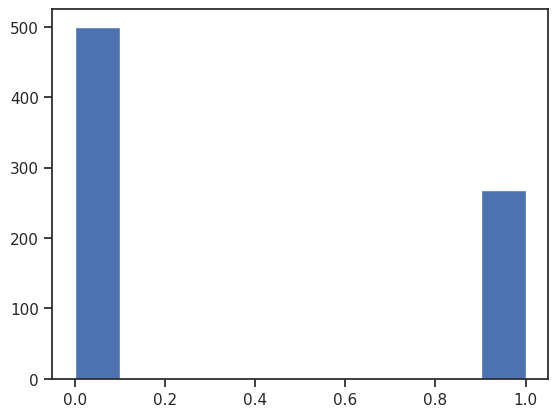

In [ ]:
plt.hist(df['Outcome'])
plt.show()

# Memisahkan Label dan Feature

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Membagi Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)
print(f"Train-test split: train={len(X_train)}, test={len(X_test)}")

Train-test split: train=614, test=154


# Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)

# Imbalance

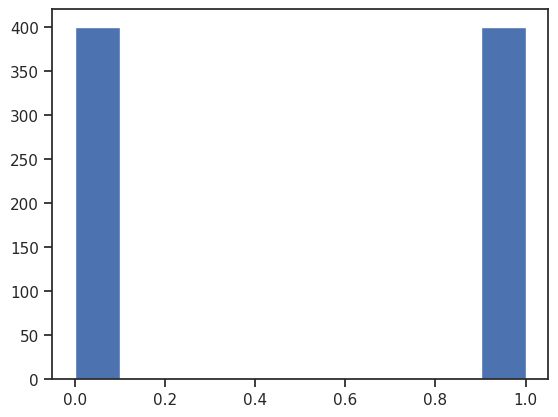

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_smote_resampled, y_smote_resampled = smote.fit_resample(X_train_scaled, y_train)

X_smote = pd.DataFrame(X_smote_resampled, columns=X.columns)
y_smote = pd.DataFrame(y_smote_resampled, columns=[y.name])

df_balanced = pd.concat([X_smote, y_smote], axis=1)
df_balanced.head()
plt.hist(df_balanced['Outcome'])
plt.show()

# HPO Algoritma K-NN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'weights':['uniform','distance'],
    'n_neighbors':[3, 5, 7, 9, 11, 13, 15],
    'metric':['euclidean','manhattan','chebyshev','minkowski']
}

classifier_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid, scoring='recall',
    cv=10, refit = True,
    verbose = 3,
    n_jobs=-1
)

y_smote = np.array(y_smote).ravel()

classifier_knn.fit(X_smote, y_smote)

print('parameter terbaik:',classifier_knn.best_params_)
print(classifier_knn.best_estimator_)

Fitting 10 folds for each of 56 candidates, totalling 560 fits
parameter terbaik: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')


# Confusion Matrix

Accuracy: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       100
           1       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



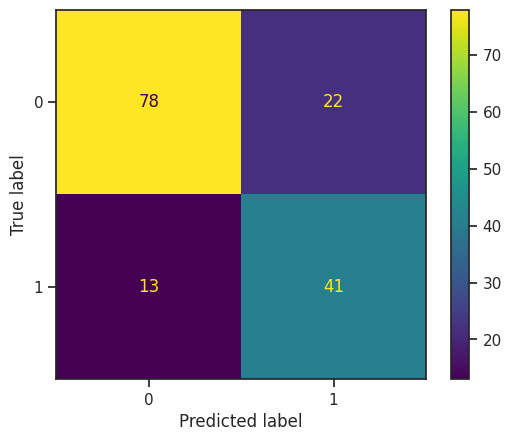

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

pred_knn = classifier_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

cm = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier_knn.classes_)
disp.plot()
plt.show()

# Save Data

In [ ]:
import joblib

filename = '/content/drive/My Drive/Tubes_Dasildat/Algoritma_K-NN.sav'
joblib.dump(classifier_knn.best_estimator_, filename)

loaded_model = joblib.load(filename)
print(loaded_model)

print('Hasil model menggunakan yang sudah di simpan:', loaded_model.score(X_smote_resampled, y_smote_resampled))
print('Hasil model menggunakan hasil training lansung:', classifier_knn.score(X_smote_resampled, y_smote_resampled))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Tubes_Dasildat/Algoritma_K-NN.sav'